# Модель Лотки–Вольтерры (хищник–жертва)

Данный скрипт демонстрирует моделирование классической системы
«хищник–жертва» с помощью обыкновенных дифференциальных уравнений (ОДУ).

## Теоретические основы

Модель Лотки–Вольтерры описывает взаимодействие двух популяций:
жертв ($x$) и хищников ($y$). Динамика задаётся системой нелинейных ОДУ:

$$\frac{dx}{dt} = \alpha x - \beta x y$$
$$\frac{dy}{dt} = \delta x y - \gamma y$$

| Параметр    | Биологический смысл                           |
|-------------|-----------------------------------------------|
| $\alpha$    | скорость естественного прироста жертв         |
| $\beta$     | интенсивность выедания жертв хищниками        |
| $\delta$    | коэффициент конверсии жертв в хищников        |
| $\gamma$    | естественная смертность хищников              |

Система имеет два положения равновесия:
- тривиальное: $(0, 0)$ (вымирание обоих видов);
- нетривиальное: $\bigl(x^* = \gamma/\delta,\; y^* = \alpha/\beta\bigr)$.

Вблизи нетривиального равновесия решения образуют **замкнутые орбиты** —
вечные незатухающие колебания обеих популяций.

## Подключение пакетов

In [1]:
using DrWatson
@quickactivate "lab_02_models"
using DifferentialEquations
using DataFrames
using StatsPlots
using LaTeXStrings
using Plots
using Statistics
using FFTW

## Настройка рабочих директорий

В скрипте папки для графиков и данных создаются автоматически.
В ноутбуке путь задаётся явно.

In [2]:
script_name = "lv_ode"

"lv_ode"

## Определение правой части системы ОДУ

Функция `lotka_volterra!` вычисляет производные вектора состояния `u = [x, y]`
in-place (записывает результат в вектор `du`).
Параметры `p = [α, β, δ, γ]` передаются через аргумент задачи.

In [3]:
function lotka_volterra!(du, u, p, t)
    x, y = u          # x — жертвы, y — хищники
    α, β, δ, γ = p   # параметры модели
    @inbounds begin
        du[1] = α*x - β*x*y   # уравнение для жертв
        du[2] = δ*x*y - γ*y   # уравнение для хищников
    end
    nothing
end

lotka_volterra! (generic function with 1 method)

## Параметры модели и начальные условия

Используем классические значения, при которых возникают устойчивые колебания.
Единицы времени условные (могут соответствовать месяцам или сезонам).

In [4]:
p_lv = [0.1,    # α: скорость размножения жертв
        0.02,   # β: скорость поедания жертв хищниками
        0.01,   # δ: коэффициент конверсии пищи в хищников
        0.3]    # γ: смертность хищников

u0_lv    = [40.0, 9.0]     # начальная популяция: [жертвы, хищники]
tspan_lv = (0.0, 200.0)    # длительность симуляции
dt_lv    = 0.01            # шаг интегрирования

0.01

## Численное решение задачи

Используем метод Цицерини (Tsit5) — явный метод Рунге–Кутты 5-го порядка
с адаптивным контролем шага. Он оптимален для нежёстких задач.

In [5]:
prob_lv = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_lv)
sol_lv  = solve(prob_lv, Tsit5(),
    dt      = dt_lv,
    reltol  = 1e-8,
    abstol  = 1e-10,
    saveat  = 0.1,
    dense   = true)

┌ Warning: Verbosity toggle: dense_output_saveat 
│  Dense output is incompatible with saveat. Please use the SavingCallback from the Callback Library to mix the two behaviors.
└ @ OrdinaryDiffEqCore ~/.julia/packages/OrdinaryDiffEqCore/MfUJb/src/solve.jl:133


retcode: Success
Interpolation: specialized 4th order "free" interpolation
t: 2001-element Vector{Float64}:
   0.0
   0.1
   0.2
   0.3
   0.4
   0.5
   0.6
   0.7
   0.8
   0.9
   1.0
   1.1
   1.2
   ⋮
 198.9
 199.0
 199.1
 199.2
 199.3
 199.4
 199.5
 199.6
 199.7
 199.8
 199.9
 200.0
u: 2001-element Vector{Vector{Float64}}:
 [40.0, 9.0]
 [39.67773201890384, 9.088990237207637]
 [39.35113789503168, 9.175882726306998]
 [39.02053587808482, 9.260562174341327]
 [38.68624820281499, 9.342916311942014]
 [38.34860018759226, 9.422836265415745]
 [38.007919320045765, 9.5002169187062]
 [37.664534369328166, 9.574957250330058]
 [37.31877446654823, 9.646960666854817]
 [36.9709682176784, 9.716135308317774]
 [36.62144287329974, 9.782394321389948]
 [36.270523365122514, 9.845656154267312]
 [35.91853163311434, 9.905844751305578]
 ⋮
 [17.88967563421412, 5.712401894068302]
 [17.86543624231875, 5.643570483722269]
 [17.843673453877365, 5.5754402198919735]
 [17.824353144929315, 5.508019318506856]
 [17.8074420

## Подготовка данных

Сохраняем решение в `DataFrame` и аналитически вычисляем производные
для дальнейшего анализа динамики.

In [6]:
df_lv = DataFrame()
df_lv[!, :t]        = sol_lv.t
df_lv[!, :prey]     = [u[1] for u in sol_lv.u]
df_lv[!, :predator] = [u[2] for u in sol_lv.u]

df_lv[!, :dprey_dt]     = p_lv[1] .* df_lv.prey .- p_lv[2] .* df_lv.prey .* df_lv.predator
df_lv[!, :dpredator_dt] = p_lv[3] .* df_lv.prey .* df_lv.predator .- p_lv[4] .* df_lv.predator

2001-element Vector{Float64}:
  0.9000000000000004
  0.8796081183812872
  0.8580494468233599
  0.8353523334488111
  0.8115489002365717
  0.7866749261310111
  0.7607697060793308
  0.7338758893000268
  0.706039294083721
  0.677308704329461
  0.6477356516317538
  0.6173741696029547
  0.5862805551332175
  ⋮
 -0.6917903984489675
 -0.6848226585569588
 -0.6777687195139261
 -0.6706369809304658
 -0.6634355041663761
 -0.6561720201747897
 -0.648853939485278
 -0.6414883588865488
 -0.6340820722589682
 -0.6266415740257949
 -0.6191730642026259
 -0.611682463105866

## Положения равновесия

Нетривиальная стационарная точка:
$$x^* = \frac{\gamma}{\delta}, \quad y^* = \frac{\alpha}{\beta}$$

In [7]:
x_star = p_lv[4] / p_lv[3]
y_star = p_lv[1] / p_lv[2]

println("="^60)
println("Модель Лотки–Вольтерры")
println("="^60)
println("Параметры: α=$(p_lv[1]), β=$(p_lv[2]), δ=$(p_lv[3]), γ=$(p_lv[4])")
println("Начальные условия: x₀=$(u0_lv[1]), y₀=$(u0_lv[2])")
println("Стационарная точка: x* = $(round(x_star, digits=3)), y* = $(round(y_star, digits=3))")

Модель Лотки–Вольтерры
Параметры: α=0.1, β=0.02, δ=0.01, γ=0.3
Начальные условия: x₀=40.0, y₀=9.0
Стационарная точка: x* = 30.0, y* = 5.0


## Визуализация результатов

### График 1: Динамика популяций во времени

Показывает циклические колебания обеих популяций.
Пунктирные линии обозначают уровни стационарного равновесия.

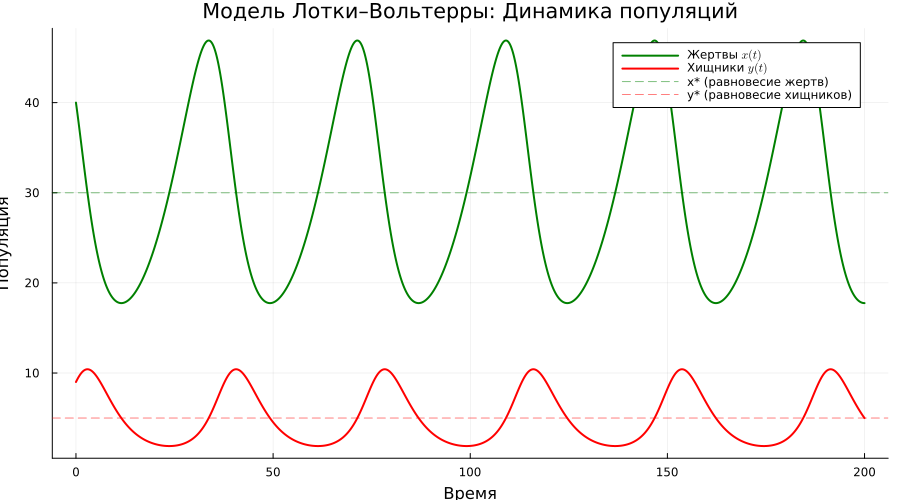

In [8]:
plt1 = plot(df_lv.t, [df_lv.prey df_lv.predator],
    label     = [L"Жертвы $x(t)$" L"Хищники $y(t)$"],
    xlabel    = "Время",
    ylabel    = "Популяция",
    title     = "Модель Лотки–Вольтерры: Динамика популяций",
    linewidth = 2,
    legend    = :topright,
    grid      = true,
    size      = (900, 500),
    color     = [:green :red])
hline!(plt1, [x_star], color=:green, linestyle=:dash, alpha=0.5, label="x* (равновесие жертв)")
hline!(plt1, [y_star], color=:red,   linestyle=:dash, alpha=0.5, label="y* (равновесие хищников)")

### График 2: Фазовый портрет

Замкнутые траектории на плоскости $(x, y)$ подтверждают
периодический характер колебаний.
Красная и зелёная пунктирные линии — **нулевые изоклины**
(линии, где производная соответствующей популяции равна нулю).

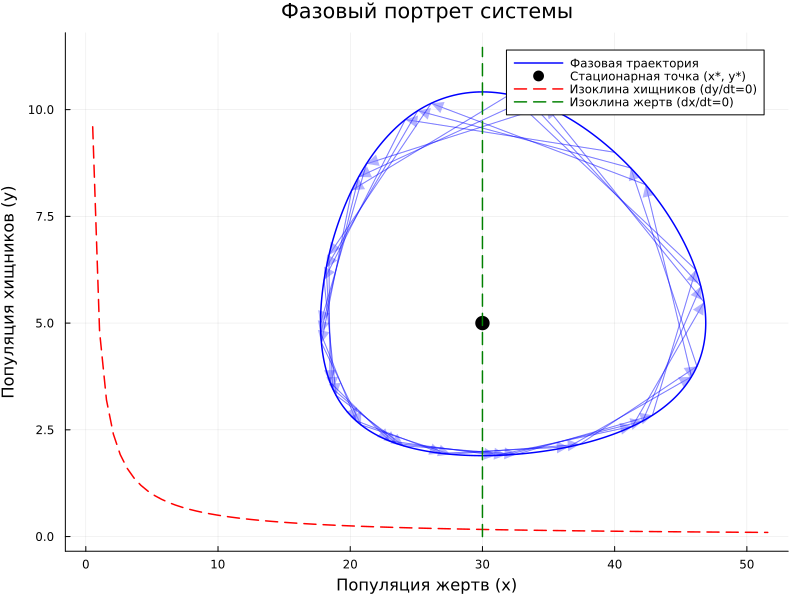

In [9]:
plt2 = plot(df_lv.prey, df_lv.predator,
    label     = "Фазовая траектория",
    xlabel    = "Популяция жертв (x)",
    ylabel    = "Популяция хищников (y)",
    title     = "Фазовый портрет системы",
    color     = :blue,
    linewidth = 1.5,
    grid      = true,
    size      = (800, 600),
    legend    = :topright)

# Стрелки направления движения
step = 50
for i in 1:step:length(df_lv.prey)-step
    plot!(plt2,
        [df_lv.prey[i], df_lv.prey[i+step]],
        [df_lv.predator[i], df_lv.predator[i+step]],
        arrow=:closed, color=:blue, alpha=0.3, label=false)
end

scatter!(plt2, [x_star], [y_star],
    color=:black, markersize=8, label="Стационарная точка (x*, y*)")

# Нулевые изоклины
x_range    = LinRange(0, maximum(df_lv.prey)*1.1, 100)
y_nullcline = p_lv[1] ./ (p_lv[2] .* x_range)
plot!(plt2, x_range, y_nullcline,
    color=:red, linestyle=:dash, linewidth=1.5, label="Изоклина хищников (dy/dt=0)")

y_range    = LinRange(0, maximum(df_lv.predator)*1.1, 100)
x_nullcline = p_lv[4] ./ (p_lv[3] .* ones(length(y_range)))
plot!(plt2, x_nullcline, y_range,
    color=:green, linestyle=:dash, linewidth=1.5, label="Изоклина жертв (dx/dt=0)")

### График 3: Производные (скорости изменения)

Знак производной показывает, растёт или убывает популяция в данный момент.

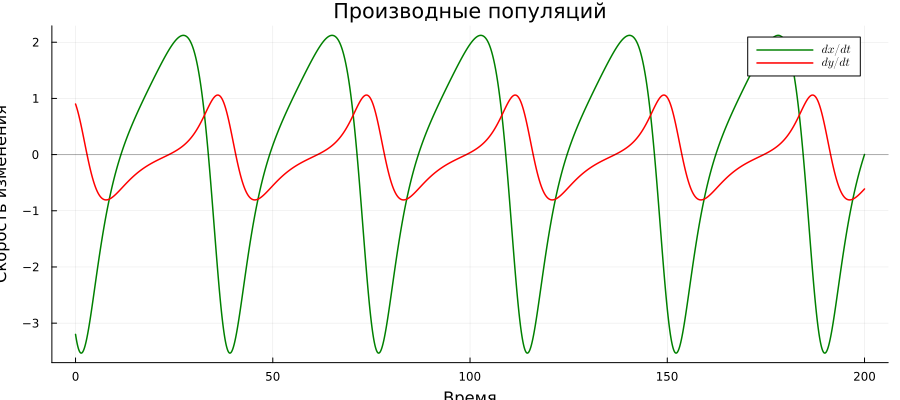

In [10]:
plt3 = plot(df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
    label     = [L"dx/dt" L"dy/dt"],
    xlabel    = "Время",
    ylabel    = "Скорость изменения",
    title     = "Производные популяций",
    linewidth = 1.5,
    legend    = :topright,
    grid      = true,
    size      = (900, 400),
    color     = [:green :red])
hline!(plt3, [0], color=:black, linestyle=:solid, alpha=0.3, label=false)

### График 4: Относительные темпы роста

Относительные темпы $dx/(x\,dt)$ и $dy/(y\,dt)$ характеризуют
скорость роста популяции в расчёте на одну особь.

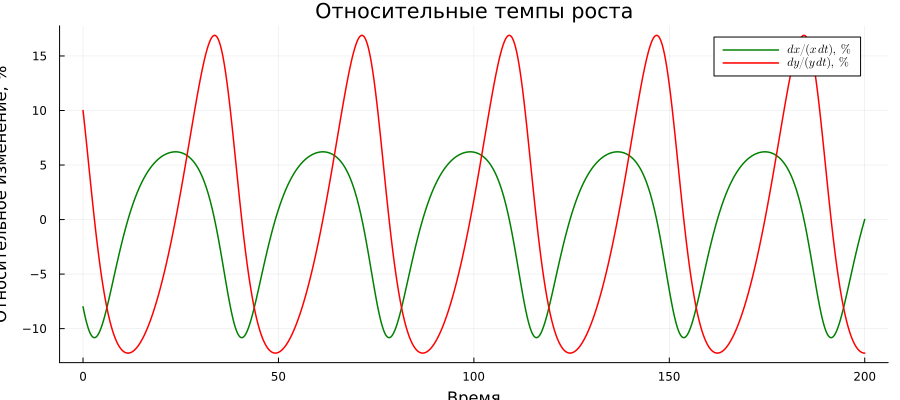

In [11]:
df_lv[!, :prey_pct_change]     = df_lv.dprey_dt ./ df_lv.prey .* 100
df_lv[!, :predator_pct_change] = df_lv.dpredator_dt ./ df_lv.predator .* 100

plt4 = plot(df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
    label     = [L"dx/(x\,dt),\;\%" L"dy/(y\,dt),\;\%"],
    xlabel    = "Время",
    ylabel    = "Относительное изменение, %",
    title     = "Относительные темпы роста",
    linewidth = 1.5,
    legend    = :topright,
    grid      = true,
    size      = (900, 400),
    color     = [:green :red])

### График 5: Спектральный анализ (БПФ)

Быстрое преобразование Фурье (БПФ) позволяет определить
**доминирующие частоты** и период колебаний популяций.

In [12]:
function compute_fft(signal, dt)
    n        = length(signal)
    spectrum = abs.(rfft(signal))
    freq     = rfftfreq(n, 1/dt)
    return freq, spectrum
end

freq_prey,     spectrum_prey     = compute_fft(df_lv.prey     .- mean(df_lv.prey),     dt_lv)
freq_predator, spectrum_predator = compute_fft(df_lv.predator .- mean(df_lv.predator), dt_lv)

plt5 = plot(freq_prey, [spectrum_prey spectrum_predator],
    label     = [L"Жертвы $x$" L"Хищники $y$"],
    xlabel    = "Частота",
    ylabel    = "Амплитуда",
    title     = "Спектральный анализ (БПФ)",
    linewidth = 1.5,
    xscale    = :log10,
    yscale    = :log10,
    legend    = :topright,
    grid      = true,
    size      = (800, 400),
    color     = [:green :red])

# Определение периода колебаний
if length(spectrum_prey) > 1
    idx_prey           = argmax(spectrum_prey[2:end]) + 1
    dominant_freq_prey = freq_prey[idx_prey]
    period_prey        = 1 / dominant_freq_prey
    println("Доминирующая частота жертв: $(round(dominant_freq_prey, digits=4))")
    println("Период колебаний:           $(round(period_prey, digits=2)) ед. времени")
end

Доминирующая частота жертв: 0.2499


Период колебаний:           4.0 ед. времени


### График 6: Сводная панель

Все ключевые графики в одном компактном виде.

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


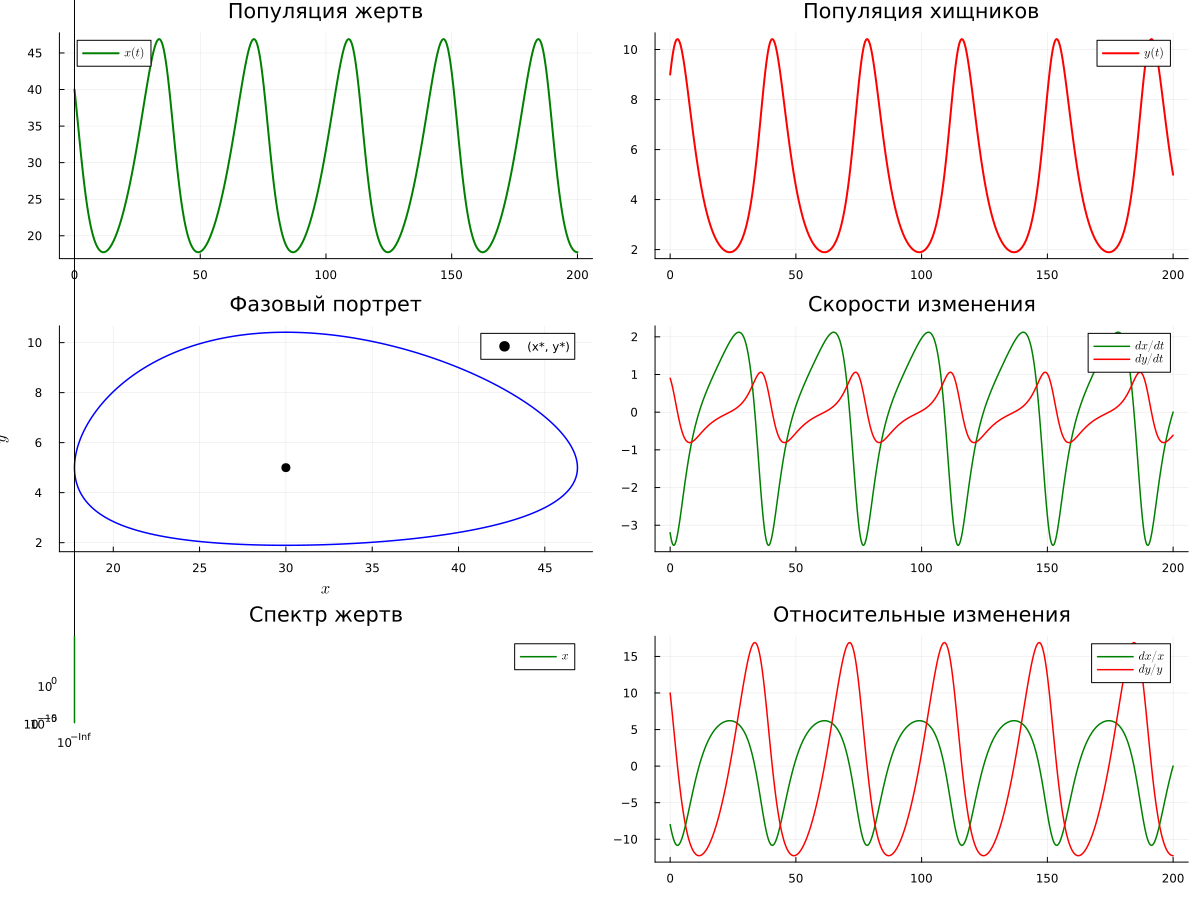

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: Invalid negative or zero value 0.0 found at series index 1 for log10 based xscale
└ @ Plots ~/.julia/packages/Plots/GIume/src/utils.jl:105


In [13]:
plt6 = plot(layout=(3, 2), size=(1200, 900))
plot!(plt6[1], df_lv.t, df_lv.prey,
    label=L"x(t)", color=:green, linewidth=2, title="Популяция жертв", grid=true)
plot!(plt6[2], df_lv.t, df_lv.predator,
    label=L"y(t)", color=:red, linewidth=2, title="Популяция хищников", grid=true)
plot!(plt6[3], df_lv.prey, df_lv.predator,
    label=false, color=:blue, linewidth=1.5,
    title="Фазовый портрет", xlabel=L"x", ylabel=L"y", grid=true)
scatter!(plt6[3], [x_star], [y_star], color=:black, markersize=5, label="(x*, y*)")
plot!(plt6[4], df_lv.t, [df_lv.dprey_dt df_lv.dpredator_dt],
    label=[L"dx/dt" L"dy/dt"], color=[:green :red], linewidth=1.5,
    title="Скорости изменения", grid=true, legend=:topright)
plot!(plt6[5], freq_prey, spectrum_prey,
    label=L"x", color=:green, linewidth=1.5,
    title="Спектр жертв", xscale=:log10, yscale=:log10, grid=true)
plot!(plt6[6], df_lv.t, [df_lv.prey_pct_change df_lv.predator_pct_change],
    label=[L"dx/x" L"dy/y"], color=[:green :red], linewidth=1.5,
    title="Относительные изменения", grid=true, legend=:topright)

## Статистический анализ результатов

In [14]:
println("\n" * "="^60)
println("Основные статистики:")
println("Жертвы:  min=$(round(minimum(df_lv.prey),     digits=2))  " *
        "max=$(round(maximum(df_lv.prey),     digits=2))  " *
        "mean=$(round(mean(df_lv.prey),       digits=2))")
println("Хищники: min=$(round(minimum(df_lv.predator), digits=2))  " *
        "max=$(round(maximum(df_lv.predator), digits=2))  " *
        "mean=$(round(mean(df_lv.predator),   digits=2))")


Основные статистики:
Жертвы:  min=17.75  max=46.89  mean=29.71
Хищники: min=1.9  max=10.41  mean=5.2


## Анализ колебаний: определение сдвига фаз

Хищники «реагируют» на рост жертв с запаздыванием —
это классический **сдвиг фаз** в цикле хищник–жертва.

In [15]:
function find_first_peak(signal, time)
    for i in 2:length(signal)-1
        if signal[i] > signal[i-1] && signal[i] > signal[i+1]
            return time[i], signal[i]
        end
    end
    return NaN, NaN
end

peak_time_prey,     peak_value_prey     = find_first_peak(df_lv.prey,     df_lv.t)
peak_time_predator, peak_value_predator = find_first_peak(df_lv.predator, df_lv.t)

if !isnan(peak_time_prey) && !isnan(peak_time_predator)
    phase_shift = peak_time_predator - peak_time_prey
    println("\nАнализ колебаний:")
    println("  Пик жертв:    t=$(round(peak_time_prey,     digits=2)), " *
            "значение=$(round(peak_value_prey,     digits=2))")
    println("  Пик хищников: t=$(round(peak_time_predator, digits=2)), " *
            "значение=$(round(peak_value_predator, digits=2))")
    println("  Сдвиг фаз (хищники отстают): $(round(phase_shift, digits=2)) ед. времени")
end

println("\nМоделирование завершено успешно!")


Анализ колебаний:
  Пик жертв:    t=33.7, значение=46.89
  Пик хищников: t=2.9, значение=10.41
  Сдвиг фаз (хищники отстают): -30.8 ед. времени

Моделирование завершено успешно!


## Анализ чувствительности к параметрам

Исследуем влияние ключевых параметров на динамику системы,
варьируя по одному параметру за раз при фиксированных остальных.

| Сценарий | Изменение | Биологический смысл |
|----------|-----------|---------------------|
| Базовый  | α=0.10, β=0.02, γ=0.30 | отправная точка |
| Быстрый прирост жертв | α=0.20 | жертвы размножаются вдвое быстрее |
| Усиленное хищничество | β=0.04 | удвоенная интенсивность выедания |
| Высокая выживаемость хищников | γ=0.15 | снижена смертность хищников вдвое |

Равновесие системы: $x^* = \gamma/\delta$ зависит только от γ и δ,
а $y^* = \alpha/\beta$ — только от α и β. Период колебаний
определяется формулой $T \approx 2\pi/\sqrt{\alpha\gamma}$.

In [16]:
param_sets_lv = [
    (label="Базовый (α=0.10, β=0.02, γ=0.30)",      α=0.10, β=0.02, δ=0.01, γ=0.30),
    (label="α=0.20 — быстрый прирост жертв",         α=0.20, β=0.02, δ=0.01, γ=0.30),
    (label="β=0.04 — усиленное хищничество",         α=0.10, β=0.04, δ=0.01, γ=0.30),
    (label="γ=0.15 — высокая выживаемость хищников", α=0.10, β=0.02, δ=0.01, γ=0.15),
]

4-element Vector{@NamedTuple{label::String, α::Float64, β::Float64, δ::Float64, γ::Float64}}:
 (label = "Базовый (α=0.10, β=0.02, γ=0.30)", α = 0.1, β = 0.02, δ = 0.01, γ = 0.3)
 (label = "α=0.20 — быстрый прирост жертв", α = 0.2, β = 0.02, δ = 0.01, γ = 0.3)
 (label = "β=0.04 — усиленное хищничество", α = 0.1, β = 0.04, δ = 0.01, γ = 0.3)
 (label = "γ=0.15 — высокая выживаемость хищников", α = 0.1, β = 0.02, δ = 0.01, γ = 0.15)

Прогоняем модель для каждого набора параметров.
Для каждого сценария вычисляем положение равновесия, амплитуду и период колебаний.

In [17]:
sweep_results_lv = DataFrame(
    сценарий         = String[],
    x_star           = Float64[],
    y_star           = Float64[],
    x_max            = Float64[],
    x_mean           = Float64[],
    y_max            = Float64[],
    y_mean           = Float64[],
    период_T         = Float64[],
    T_теоретический  = Float64[],
)

solutions_lv = []

for ps in param_sets_lv
    p_test    = [ps.α, ps.β, ps.δ, ps.γ]
    prob_test = ODEProblem(lotka_volterra!, u0_lv, tspan_lv, p_test)
    sol_test  = solve(prob_test, Tsit5(), reltol=1e-8, abstol=1e-10, saveat=0.1)

    prey_vals = [u[1] for u in sol_test.u]
    pred_vals = [u[2] for u in sol_test.u]

    # Период колебаний через БПФ (dt = 0.1 соответствует saveat=0.1)
    freq_s, spec_s = compute_fft(prey_vals .- mean(prey_vals), 0.1)
    period_s = length(spec_s) > 1 ? 1 / freq_s[argmax(spec_s[2:end]) + 1] : NaN

    # Теоретический период: T ≈ 2π / √(α·γ)
    T_theory = 2π / sqrt(ps.α * ps.γ)

    push!(solutions_lv, (t=sol_test.t, prey=prey_vals, predator=pred_vals, label=ps.label))
    push!(sweep_results_lv, (
        ps.label,
        round(ps.γ / ps.δ,       digits=2),
        round(ps.α / ps.β,       digits=2),
        round(maximum(prey_vals), digits=2),
        round(mean(prey_vals),    digits=2),
        round(maximum(pred_vals), digits=2),
        round(mean(pred_vals),    digits=2),
        round(period_s,           digits=2),
        round(T_theory,           digits=2),
    ))
end

println("\n" * "="^60)
println("Результаты анализа чувствительности (Лотки–Вольтерра)")
println("="^60)
println(sweep_results_lv)

Результаты анализа чувствительности (Лотки–Вольтерра)
4×9 DataFrame
 Row │ сценарий                           x_star   y_star   x_max    x_mean   y_max    y_mean   период_T  T_теоретический 
     │ String                             Float64  Float64  Float64  Float64  Float64  Float64  Float64   Float64         
─────┼────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ Базовый (α=0.10, β=0.02, γ=0.30)      30.0      5.0    46.89    29.71    10.41     5.2      40.02            36.28
   2 │ α=0.20 — быстрый прирост жертв        30.0     10.0    40.42    29.86    14.35    10.1      25.01            25.65
   3 │ β=0.04 — усиленное хищничество        30.0      2.5    69.96    28.32     9.47     2.49     40.02            36.28
   4 │ γ=0.15 — высокая выживаемость хи…     15.0      5.0    43.32    14.7     17.46     5.65     66.7             51.3


### График S1: Динамика жертв — сравнение сценариев

Увеличение α ускоряет колебания; рост β снижает амплитуду жертв;
снижение γ удерживает больше хищников, что подавляет жертв.

In [18]:
plt_s1 = plot(xlabel="Время", ylabel="Популяция жертв (x)",
    title="Сравнение сценариев: динамика жертв",
    grid=true, size=(1000, 450), legend=:topright)
for (i, s) in enumerate(solutions_lv)
    plot!(plt_s1, s.t, s.prey, label=s.label, linewidth=1.8, color=i)
end

### График S2: Динамика хищников — сравнение сценариев

In [19]:
plt_s2 = plot(xlabel="Время", ylabel="Популяция хищников (y)",
    title="Сравнение сценариев: динамика хищников",
    grid=true, size=(1000, 450), legend=:topright)
for (i, s) in enumerate(solutions_lv)
    plot!(plt_s2, s.t, s.predator, label=s.label, linewidth=1.8, color=i)
end

### График S3: Фазовые портреты — сравнение сценариев

Различные орбиты в пространстве $(x, y)$: изменение параметров
меняет форму, размер и положение орбиты.

In [20]:
plt_s3 = plot(xlabel="Жертвы (x)", ylabel="Хищники (y)",
    title="Фазовые портреты: сравнение сценариев",
    grid=true, size=(800, 600), legend=:topright)
for (i, s) in enumerate(solutions_lv)
    plot!(plt_s3, s.prey, s.predator, label=s.label, linewidth=1.5, color=i)
end

### График S4: Сводная панель анализа чувствительности

In [21]:
plt_s4 = plot(layout=(1, 3), size=(1400, 450))
for (i, s) in enumerate(solutions_lv)
    plot!(plt_s4[1], s.t, s.prey,
        label=s.label, linewidth=1.5, color=i,
        title="Жертвы", xlabel="t", ylabel="x", legend=:topright, grid=true)
    plot!(plt_s4[2], s.t, s.predator,
        label=false, linewidth=1.5, color=i,
        title="Хищники", xlabel="t", ylabel="y", grid=true)
    plot!(plt_s4[3], s.prey, s.predator,
        label=false, linewidth=1.5, color=i,
        title="Фазовые портреты", xlabel="x", ylabel="y", grid=true)
end